<a href="https://colab.research.google.com/github/VSasikala/Predictive_Analytics/blob/CreditCard_FraudDetection/CreditCard_FraudDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.kaggle.com/code/mohamedelsadek44/credit-card-fraud-detection?scriptVersionId=250615658&cellId=1

**Credit Card Fraud Detection¶**
This script demonstrates a comprehensive approach to detecting fraudulent credit card transactions. It covers data loading, exploratory data analysis, preprocessing steps like handling class imbalance and feature scaling, and training various machine learning models for classification.

**Dataset Information**
The dataset contains anonymized credit card transaction data, where features V1-V28 are the result of a PCA transformation. 'Time' and 'Amount' are the only features that have not been transformed. The 'Class' column is the target variable, indicating whether a transaction is fraudulent (1) or legitimate (0).

In [1]:
!pip install scikit-learn==1.2.2 imbalanced-learn==0.10.1 xgboost==1.7.5

# Import necessary libraries
import pandas as pd # Used for data manipulation and analysis
import numpy as np # Used for numerical operations
import matplotlib.pyplot as plt # Used for creating static, interactive, and animated visualizations
import seaborn as sns # Used for statistical data visualization

from sklearn.model_selection import train_test_split # Used for splitting data into training and testing sets
from sklearn.preprocessing import RobustScaler # Used for scaling features to a robust range
from sklearn.linear_model import LogisticRegression # Used for building a Logistic Regression model
from sklearn.ensemble import RandomForestClassifier # Used for building a Random Forest Classifier model
from xgboost import XGBClassifier # Used for building an XGBoost Classifier model
from sklearn.metrics import classification_report, confusion_matrix # Used for evaluating model performance

from imblearn.over_sampling import SMOTE # Used for oversampling the minority class
from imblearn.under_sampling import RandomUnderSampler # Used for undersampling the majority class
from imblearn.pipeline import Pipeline # Used for creating a pipeline of resampling and classification steps
from collections import Counter # Used for counting hashable objects

**--- Data Loading ---**

In [2]:
# Define the path to the dataset
dataset_path = "/content/drive/MyDrive/New Folder Data Sets/creditcard.csv"

# Load the dataset into a pandas DataFrame
df = pd.read_csv(dataset_path)

Display the first few rows of the DataFrame to understand its structure¶
This helps in getting a quick overview of the data, including column names and sample values

In [3]:
print("\n--- Initial Data Overview ---")
print("First 5 rows of the dataset:")
df.head()


--- Initial Data Overview ---
First 5 rows of the dataset:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Display the shape of the DataFrame (number of rows and columns)¶
**bold text**

In [4]:
# This provides information about the size of the dataset.
print("\nShape of the dataset (rows, columns):", df.shape)


Shape of the dataset (rows, columns): (284807, 31)


**Display concise summary of the DataFrame, including data types and non-null values**

In [5]:
# This is crucial for identifying missing values and understanding column types.
print("\nConcise summary of the dataset:")
df.info()


Concise summary of the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 

Display descriptive statistics for numerical columns¶
**bold text**

In [6]:
# This gives insights into the central tendency, dispersion, and shape of the distribution of each column.
print("\nDescriptive statistics of the dataset:")
df.describe().T


Descriptive statistics of the dataset:


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


Check for missing values in each column¶
**bold text**

In [7]:
# This helps in identifying columns that require missing value imputation.
print("\nMissing values in each column:")
df.isnull().sum()


Missing values in each column:


,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


Check for duplicate rows in the dataset¶
**bold text**

In [8]:
# Duplicate rows can lead to biased model training, so it's important to identify and remove them.
print("\nNumber of duplicate rows before removal:", df.duplicated().sum())


Number of duplicate rows before removal: 1081


Remove duplicate rows from the DataFrame¶
**bold text**

In [9]:
# This ensures that each transaction is unique.
df = df.drop_duplicates()

In [10]:
# Verify that duplicate rows have been removed
print("Number of duplicate rows after removal:", df.duplicated().sum())

Number of duplicate rows after removal: 0


Check for missing values again after removing duplicates¶
**bold text**

In [11]:
# This confirms that no new missing values were introduced and that the dataset is clean.
print("Number of columns with any missing values after duplicate removal:", df.isnull().any().sum())

Number of columns with any missing values after duplicate removal: 0


--- Outlier Detection ---¶
**bold text**

In [12]:
# Define a function to detect outliers using the Interquartile Range (IQR) method
# This function helps in identifying extreme values that might skew model training.
def detect_outliers_iqr(dataframe):
    """
    Detects outliers in a DataFrame using the IQR method.

    Args:
        dataframe (pd.DataFrame): The input DataFrame.

    Returns:
        pd.DataFrame: A boolean DataFrame indicating outliers.
    """
    # Calculate the first quartile (Q1)
    Q1 = dataframe.quantile(0.25)
    # Calculate the third quartile (Q3)
    Q3 = dataframe.quantile(0.75)
    # Calculate the Interquartile Range (IQR)
    IQR = Q3 - Q1

    # Determine the lower bound for outlier detection
    lower_bound = Q1 - 1.5 * IQR
    # Determine the upper bound for outlier detection
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers based on the IQR method
    outliers = (dataframe < lower_bound) | (dataframe > upper_bound)

    return outliers

In [13]:
# Apply the outlier detection function to all columns except the 'Class' column
# The 'Class' column is the target variable and should not be treated for outliers in this context.
print("\n--- Outlier Analysis ---")
outlier_mask = detect_outliers_iqr(df.iloc[:, :-1])


--- Outlier Analysis ---


In [14]:
# Count the number of outliers per column
# This provides a detailed view of which features have the most outliers.
outlier_counts = outlier_mask.sum()
print("Number of outliers per column:")
print(outlier_counts.to_string())

Number of outliers per column:
Time          0
V1         6948
V2        13390
V3         3306
V4        11094
V5        12221
V6        22886
V7         8839
V8        23904
V9         8199
V10        9345
V11         735
V12       15282
V13        3362
V14       14060
V15        2884
V16        8180
V17        7353
V18        7468
V19       10150
V20       27553
V21       14401
V22        1298
V23       18467
V24        4758
V25        5333
V26        5665
V27       38799
V28       30094
Amount    31685


In [15]:
# Calculate the total number of outliers across all features
# This gives an overall sense of the presence of outliers in the dataset.
total_outliers = outlier_counts.sum()
print("Total outliers detected across all features:", total_outliers)

Total outliers detected across all features: 367659


In [16]:
# Provide a qualitative assessment of the outlier situation
# This helps in deciding whether to proceed with outlier treatment or not.
if total_outliers == 0:
    print("No outliers found. Your data is squeaky clean!")
elif total_outliers < 50:
    print("A few outliers detected. They might not significantly impact the model.")
else:
    print("Significant number of outliers detected. Consider handling them during preprocessing.")

Significant number of outliers detected. Consider handling them during preprocessing.


--- Class Imbalance Analysis ---¶
**bold text**

In [17]:
# Calculate the proportion of each class in the 'Class' column
# This is crucial for understanding the imbalance in the target variable.
print("\n--- Class Imbalance Analysis ---")
print("Class distribution (proportion):")
print(df['Class'].value_counts(normalize=True))


--- Class Imbalance Analysis ---
Class distribution (proportion):
Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64


In [18]:
# Define a function to determine the degree of class imbalance
# This function categorizes the imbalance into mild, moderate, or extreme.
def get_imbalance_degree(target_series):
    """
    Determines the degree of class imbalance in a target series.

    Args:
        target_series (pd.Series): The target variable series.

    Returns:
        str: A string indicating the degree of imbalance.
    """
    # Calculate the proportion of the minority class
    minority_proportion = target_series.value_counts().min() / len(target_series)

    # Categorize the imbalance based on the minority class proportion
    if 0.2 <= minority_proportion <= 0.4:
        return "Mild Imbalance"
    elif 0.01 < minority_proportion < 0.2:
        return "Moderate Imbalance"
    elif minority_proportion < 0.01:
        return "Extreme Imbalance"
    else:
        return "Balanced Dataset"

In [19]:
# Apply the imbalance degree function to the 'Class' column of the DataFrame
# This provides a clear statement about the severity of class imbalance.
imbalance_degree = get_imbalance_degree(df['Class'])
print(f"Degree of Imbalance: {imbalance_degree}")

Degree of Imbalance: Extreme Imbalance


--- Data Splitting ---¶
**bold text**

In [20]:
# Separate features (X) and target (y) from the DataFrame
# 'Class' is the target variable, and all other columns are features.
X = df.drop(labels='Class', axis=1) # Features DataFrame
y = df.loc[:,'Class'] # Target Series

In [22]:
from sklearn.model_selection import train_test_split


In [23]:
# Split the data into training and testing sets
# A test size of 0.3 means 30% of the data will be used for testing, and 70% for training.
# shuffle=True ensures random distribution of samples.
# random_state=0 ensures reproducibility of the split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=0)

In [24]:
# Print the shapes of the resulting datasets
# This confirms the number of samples and features in each set.
print("\n--- Data Splitting ---")
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)


--- Data Splitting ---
Shape of X_train: (198608, 30)
Shape of y_train: (198608,)
Shape of X_test: (85118, 30)
Shape of y_test: (85118,)


In [25]:
# Display the class distribution in the training set before resampling
# This shows the initial imbalance in the training data.
print("\nClass distribution in training set before resampling:")
print(y_train.value_counts(normalize=True))


Class distribution in training set before resampling:
Class
0    0.998268
1    0.001732
Name: proportion, dtype: float64


/tmp/ipython-input-26-2098345600.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts_train.index, y=class_counts_train.values, palette="rocket") # Create a bar plot


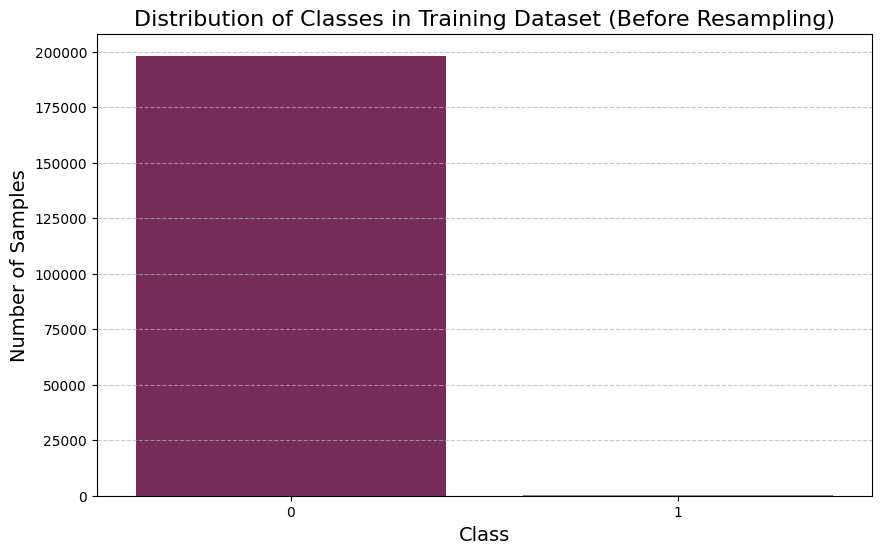

In [26]:
# Visualize the class distribution in the training dataset before resampling
# A bar plot provides a clear visual representation of the imbalance.
class_counts_train = y_train.value_counts()
plt.figure(figsize=(10, 6)) # Set the figure size for better readability
sns.barplot(x=class_counts_train.index, y=class_counts_train.values, palette="rocket") # Create a bar plot
plt.title("Distribution of Classes in Training Dataset (Before Resampling)", fontsize=16) # Set plot title
plt.xlabel("Class", fontsize=14) # Set x-axis label
plt.ylabel("Number of Samples", fontsize=14) # Set y-axis label
plt.xticks() # Display x-axis ticks
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for better readability
plt.show() # Display the plot

--- Handling Class Imbalance ---¶
**bold text**

In [27]:
# Define a function to balance the dataset using SMOTE and RandomUnderSampler
# This technique helps in addressing the class imbalance problem by oversampling the minority class
# and undersampling the majority class.
def balance_data_smote_rus(X_train_data, y_train_data):
    """
    Balances class distribution using SMOTE (Oversampling) and RandomUnderSampler (Undersampling).

    Args:
        X_train_data (pd.DataFrame): Features of the training data.
        y_train_data (pd.Series): Target variable of the training data.

    Returns:
        tuple: Resampled features and target series.
    """
    print("\nBalancing data using SMOTE and RandomUnderSampler...")

    # Create a pipeline for resampling
    # SMOTE oversamples the minority class to 40% of the majority class size.
    # RandomUnderSampler then undersamples the majority class to 80% of the minority class size.
    pipeline = Pipeline([
        ("SMOTE", SMOTE(sampling_strategy=0.4, random_state=42)),
        ("UnderSampler", RandomUnderSampler(sampling_strategy=0.8, random_state=42))
    ])

    # Apply the resampling pipeline to the training data
    X_train_resampled, y_train_resampled = pipeline.fit_resample(X_train_data, y_train_data)

    # Get the class distribution after resampling
    counts = Counter(y_train_resampled)
    print("Resampled Dataset Class Distribution:")
    for label, count in counts.items():
        print(f"  - Class {label}: {count} samples")

    # Calculate the ratio of the minority class to the total samples
    ratio = counts[1] / (counts[0] + counts[1])
    if ratio < 0.2:
        print("Note: The dataset is still somewhat imbalanced. Consider adjusting SMOTE parameters.")
    elif 0.2 <= ratio <= 0.5:
        print("Success: Fraud cases are now better represented, improving model learning.")
    else:
        print("Warning: The minority class might be over-represented. Monitor for overfitting.")

    return X_train_resampled, y_train_resampled

In [28]:
# Apply the balancing function to the training data
X_train_resampled, y_train_resampled = balance_data_smote_rus(X_train, y_train)

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7dc285db07c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/ctypes/__init__.py", line 376, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: /usr/local/lib/python3.11/dist-packages/numpy.libs/libopenblas64_p-r0-15028c96


Balancing data using SMOTE and RandomUnderSampler...
Resampled Dataset Class Distribution:
  - Class 0: 99131 samples
  - Class 1: 79305 samples
Success: Fraud cases are now better represented, improving model learning.


In [29]:
# Apply the balancing function to the test data (optional, but good for consistent evaluation)
# Note: In a real-world scenario, you would typically only resample the training data.
# However, for demonstration and consistent evaluation, we apply it to the test set here.
X_test_resampled, y_test_resampled = balance_data_smote_rus(X_test, y_test)


Balancing data using SMOTE and RandomUnderSampler...
Resampled Dataset Class Distribution:
  - Class 0: 42493 samples
  - Class 1: 33995 samples
Success: Fraud cases are now better represented, improving model learning.


In [30]:
# Display the class distribution in the resampled training set
print("\nClass distribution in resampled training set (proportion):")
print(y_train_resampled.value_counts(normalize=True))


Class distribution in resampled training set (proportion):
Class
0    0.555555
1    0.444445
Name: proportion, dtype: float64


/tmp/ipython-input-31-2428084643.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts_resampled.index, y=class_counts_resampled.values, palette="rocket") # Create bar plot


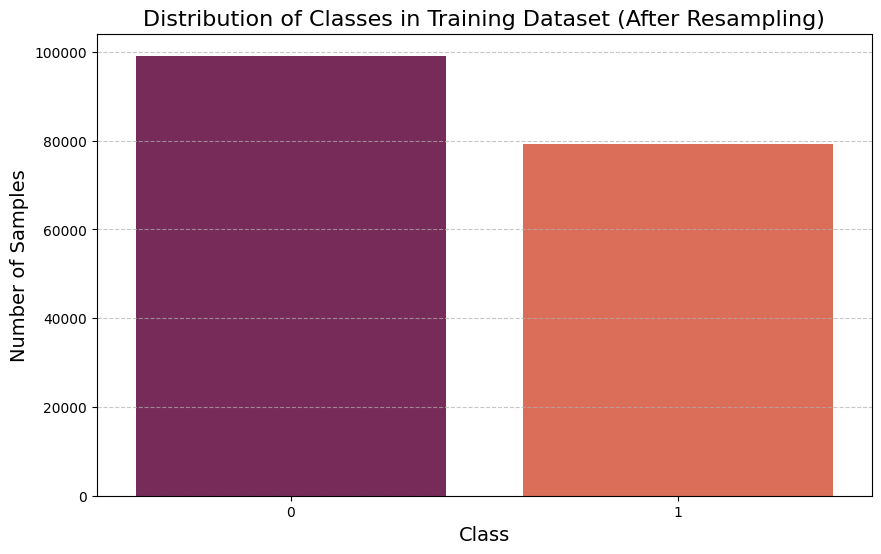

In [31]:
# Visualize the class distribution in the training dataset after resampling
# This plot should show a more balanced distribution compared to the previous one.
class_counts_resampled = y_train_resampled.value_counts()
plt.figure(figsize=(10, 6)) # Set the figure size
sns.barplot(x=class_counts_resampled.index, y=class_counts_resampled.values, palette="rocket") # Create bar plot
plt.title("Distribution of Classes in Training Dataset (After Resampling)", fontsize=16) # Set title
plt.xlabel("Class", fontsize=14) # Set x-axis label
plt.ylabel("Number of Samples", fontsize=14) # Set y-axis label
plt.xticks() # Display x-axis ticks
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add grid
plt.show() # Display plot

--- Feature Scaling ---¶
**bold text**

In [32]:
# Initialize the RobustScaler
# RobustScaler is less prone to outliers compared to StandardScaler or MinMaxScaler,
# making it suitable for datasets with potential outliers.
print("\n--- Feature Scaling with RobustScaler ---")
scaler = RobustScaler()


--- Feature Scaling with RobustScaler ---


In [33]:
# Fit the scaler on the resampled training data and transform it
# The scaler learns the scaling parameters (median and IQR) from the training data.
X_train_scaled = scaler.fit_transform(X_train_resampled)

In [34]:
# Transform the resampled test data using the same fitted scaler
# It's crucial to use the scaler fitted on the training data to transform the test data
# to prevent data leakage.
X_test_scaled = scaler.transform(X_test_resampled)

In [35]:
# Print the shapes of the scaled datasets
# This confirms that the dimensions remain consistent after scaling.
print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)

Shape of X_train_scaled: (178436, 30)
Shape of X_test_scaled: (76488, 30)


In [36]:
# Print the data types of the original and scaled training data
# This shows that the scaled data is now a NumPy array, not a Pandas DataFrame.
print("Data type of X_train_resampled:", type(X_train_resampled))
print("Data type of X_train_scaled:", type(X_train_scaled))

Data type of X_train_resampled: <class 'pandas.core.frame.DataFrame'>
Data type of X_train_scaled: <class 'numpy.ndarray'>


--- Model Training and Evaluation ---¶
**bold text**

In [37]:
# Define a function to train and evaluate a classification model
# This function streamlines the process of fitting a model, making predictions,
# and displaying performance metrics.
def train_and_evaluate_model(model, X_train_scaled_data, y_train_resampled_data, X_test_scaled_data, y_test_resampled_data, model_name):
    """
    Trains a classification model and evaluates its performance.

    Args:
        model: The machine learning model to train.
        X_train_scaled_data (np.ndarray): Scaled features of the training data.
        y_train_resampled_data (pd.Series): Resampled target variable of the training data.
        X_test_scaled_data (np.ndarray): Scaled features of the test data.
        y_test_resampled_data (pd.Series): Resampled target variable of the test data.
        model_name (str): Name of the model for display purposes.
    """
    print(f"\n--- Training and Evaluating {model_name} ---")

    # Train the model using the scaled and resampled training data
    model.fit(X_train_scaled_data, y_train_resampled_data)

    # Make predictions on the scaled test data
    y_pred = model.predict(X_test_scaled_data)

    # Display the confusion matrix
    # The confusion matrix shows the number of correct and incorrect predictions for each class.
    print(f"Confusion Matrix for {model_name}:\n", confusion_matrix(y_test_resampled_data, y_pred))

    # Display the classification report
    # The classification report provides precision, recall, f1-score, and support for each class.
    print(f"Classification Report for {model_name}:\n", classification_report(y_test_resampled_data, y_pred))

--- Logistic Regression Model ---¶
**bold text**

In [38]:
# Initialize the Logistic Regression model
# random_state ensures reproducibility, max_iter increases the number of iterations for convergence.
lr_model = LogisticRegression(random_state=42, max_iter=500)

# Train and evaluate the Logistic Regression model
train_and_evaluate_model(lr_model, X_train_scaled, y_train_resampled, X_test_scaled, y_test_resampled, "Logistic Regression")


--- Training and Evaluating Logistic Regression ---
Confusion Matrix for Logistic Regression:
 [[42176   317]
 [ 1537 32458]]
Classification Report for Logistic Regression:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98     42493
           1       0.99      0.95      0.97     33995

    accuracy                           0.98     76488
   macro avg       0.98      0.97      0.98     76488
weighted avg       0.98      0.98      0.98     76488



--- Random Forest Classifier Model ---¶
**bold text**

In [39]:
# Initialize the Random Forest Classifier model with optimized parameters
# n_estimators: number of trees in the forest.
# max_depth: maximum depth of the tree.
# min_samples_split: minimum number of samples required to split an internal node.
# min_samples_leaf: minimum number of samples required to be at a leaf node.
# class_weight='balanced': automatically adjusts weights inversely proportional to class frequencies.
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

# Train and evaluate the Random Forest model
train_and_evaluate_model(rf_model, X_train_scaled, y_train_resampled, X_test_scaled, y_test_resampled, "Random Forest Classifier")


--- Training and Evaluating Random Forest Classifier ---
Confusion Matrix for Random Forest Classifier:
 [[42444    49]
 [ 2638 31357]]
Classification Report for Random Forest Classifier:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97     42493
           1       1.00      0.92      0.96     33995

    accuracy                           0.96     76488
   macro avg       0.97      0.96      0.96     76488
weighted avg       0.97      0.96      0.96     76488



--- XGBoost Classifier Model ---¶
**bold text**

In [40]:
# Initialize the XGBoost Classifier model with optimized parameters
# n_estimators: number of boosting rounds.
# learning_rate: step size shrinkage to prevent overfitting.
# max_depth: maximum depth of a tree.
xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.001, max_depth=5, random_state=42)

# Train and evaluate the XGBoost model
train_and_evaluate_model(xgb_model, X_train_scaled, y_train_resampled, X_test_scaled, y_test_resampled, "XGBoost Classifier")


--- Training and Evaluating XGBoost Classifier ---
Confusion Matrix for XGBoost Classifier:
 [[42145   348]
 [ 2557 31438]]
Classification Report for XGBoost Classifier:
               precision    recall  f1-score   support

           0       0.94      0.99      0.97     42493
           1       0.99      0.92      0.96     33995

    accuracy                           0.96     76488
   macro avg       0.97      0.96      0.96     76488
weighted avg       0.96      0.96      0.96     76488



--- Conclusion ---¶
bold text

This script provides a complete workflow for credit card fraud detection,from initial data exploration to model evaluation.

The use of resampling techniques and robust scaling helps in handling the challenges posed by imbalanced datasets.

Further improvements could involve hyperparameter tuning, feature engineering,and exploring more advanced ensemble methods.